# Lab Report

## Name: Tasrif Nur Himel
## ID: 221-35-1078

### Course Code: DS422
### Section: B1
### Batch: 37

### setup, load data, stratified split

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold

x, y = load_breast_cancer(return_X_y=True, as_frame=True)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42
)

print("Shapes:", x_train.shape, x_test.shape)
print("Class balance (train):", np.bincount(y_train))
print("Class balance (test): ", np.bincount(y_test))


Shapes: (455, 30) (114, 30)
Class balance (train): [170 285]
Class balance (test):  [42 72]


### evaluation

In [2]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

def evaluate_model(est, name):
    y_pred = est.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} — Test Metrics")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("Confusion matrix:\n", cm)

    return {"Model": name, "Accuracy": acc, "Precision_macro": prec,
            "Recall_macro": rec, "F1_macro": f1}


### Linear SVM (GridSearchCV)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipe_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])

grid_lin = {
    "svc__C": [0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_lin = GridSearchCV(
    pipe_lin, grid_lin, scoring="accuracy", cv=cv, n_jobs=-1
)
gs_lin.fit(x_train, y_train)

print("Linear SVM — Best params:", gs_lin.best_params_)
print("Linear SVM — CV best accuracy:", gs_lin.best_score_)

best_lin = gs_lin.best_estimator_
lin_results = evaluate_model(best_lin, "Linear SVM")

Linear SVM — Best params: {'svc__C': 0.1}
Linear SVM — CV best accuracy: 0.9758241758241759

Linear SVM — Test Metrics
Accuracy:  0.9825
Precision: 0.9812
Recall:    0.9812
F1-score:  0.9812
Confusion matrix:
 [[41  1]
 [ 1 71]]


### RBF SVM (GridSearchCV)

In [4]:
pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])

grid_rbf = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.1, 0.01, 0.001]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_rbf = GridSearchCV(pipe_rbf, grid_rbf, scoring="accuracy", cv=cv, n_jobs=-1)
gs_rbf.fit(x_train, y_train)

print("RBF SVM — Best params:", gs_rbf.best_params_)
print("RBF SVM — CV best accuracy:", gs_rbf.best_score_)

best_rbf = gs_rbf.best_estimator_
rbf_results = evaluate_model(best_rbf, "RBF SVM")


RBF SVM — Best params: {'svc__C': 10, 'svc__gamma': 0.01}
RBF SVM — CV best accuracy: 0.9758241758241759

RBF SVM — Test Metrics
Accuracy:  0.9825
Precision: 0.9812
Recall:    0.9812
F1-score:  0.9812
Confusion matrix:
 [[41  1]
 [ 1 71]]


### Polynomial SVM (GridSearchCV)

In [5]:
pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly"))
])

grid_poly = {
    "svc__C": [0.1, 1, 10],
    "svc__degree": [2, 3, 4],
    "svc__gamma": ["scale", 0.1, 0.01],
    "svc__coef0": [0, 0.5, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_poly = GridSearchCV(pipe_poly, grid_poly, scoring="accuracy", cv=cv, n_jobs=-1)
gs_poly.fit(x_train, y_train)

print("Poly SVM — Best params:", gs_poly.best_params_)
print("Poly SVM — CV best accuracy:", gs_poly.best_score_)

best_poly = gs_poly.best_estimator_
poly_results = evaluate_model(best_poly, "Polynomial SVM")

Poly SVM — Best params: {'svc__C': 1, 'svc__coef0': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale'}
Poly SVM — CV best accuracy: 0.9780219780219781

Polynomial SVM — Test Metrics
Accuracy:  0.9737
Precision: 0.9697
Recall:    0.9742
F1-score:  0.9719
Confusion matrix:
 [[41  1]
 [ 2 70]]


In [7]:
import pandas as pd

lin_row  = {**lin_results,  "CV_Acc": gs_lin.best_score_,  "Best_Params": gs_lin.best_params_}
rbf_row  = {**rbf_results,  "CV_Acc": gs_rbf.best_score_,  "Best_Params": gs_rbf.best_params_}
poly_row = {**poly_results, "CV_Acc": gs_poly.best_score_, "Best_Params": gs_poly.best_params_}

cmp = pd.DataFrame([lin_row, rbf_row, poly_row]).sort_values("Accuracy", ascending=False)
cmp

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,CV_Acc,Best_Params
0,Linear SVM,0.982456,0.981151,0.981151,0.981151,0.975824,{'svc__C': 0.1}
1,RBF SVM,0.982456,0.981151,0.981151,0.981151,0.975824,"{'svc__C': 10, 'svc__gamma': 0.01}"
2,Polynomial SVM,0.973684,0.969702,0.974206,0.971863,0.978022,"{'svc__C': 1, 'svc__coef0': 1.0, 'svc__degree'..."


### Cross-validation summary

In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_report(est, name):
    acc = cross_val_score(est, x_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    f1m = cross_val_score(est, x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{name} — CV Accuracy: {acc.mean():.4f} ± {acc.std():.4f} | CV F1_macro: {f1m.mean():.4f} ± {f1m.std():.4f}")

cv_report(best_lin,  "Linear SVM")
cv_report(best_rbf,  "RBF SVM")
cv_report(best_poly, "Polynomial SVM")


Linear SVM — CV Accuracy: 0.9758 ± 0.0108 | CV F1_macro: 0.9739 ± 0.0119
RBF SVM — CV Accuracy: 0.9758 ± 0.0162 | CV F1_macro: 0.9739 ± 0.0177
Polynomial SVM — CV Accuracy: 0.9780 ± 0.0120 | CV F1_macro: 0.9765 ± 0.0127


### Confusion Matrix

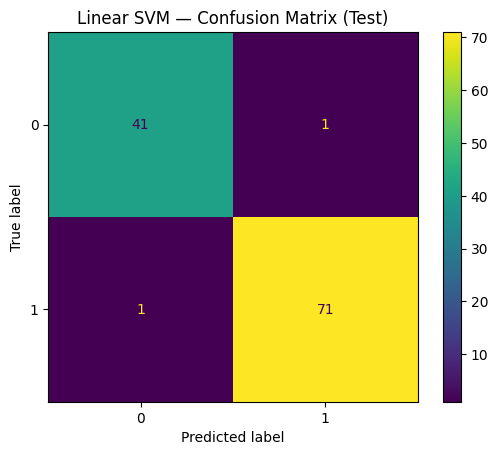

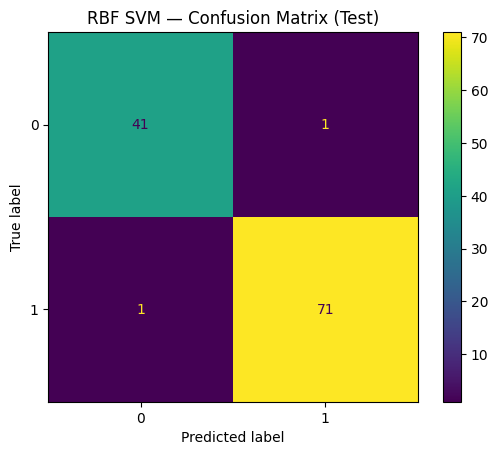

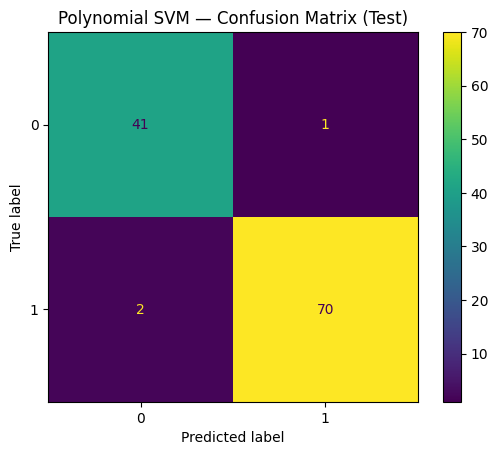

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for name, est in [("Linear SVM", best_lin), ("RBF SVM", best_rbf), ("Polynomial SVM", best_poly)]:
    ConfusionMatrixDisplay.from_estimator(est, x_test, y_test)
    plt.title(f"{name} — Confusion Matrix (Test)")
    plt.show()


### ROC curves + AUC

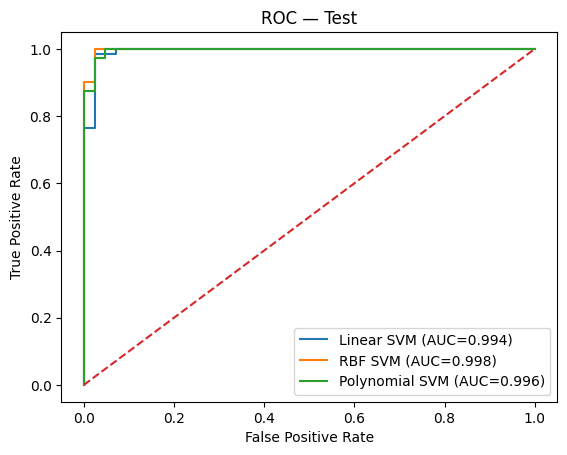

In [11]:
from sklearn.metrics import roc_curve, auc

def plot_roc(est, name):
    if hasattr(est, "decision_function"):
        scores = est.decision_function(x_test)
    else:
        scores = est.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.figure()
for name, est in [("Linear SVM", best_lin), ("RBF SVM", best_rbf), ("Polynomial SVM", best_poly)]:
    plot_roc(est, name)
plt.plot([0,1],[0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Test")
plt.legend()
plt.show()


## Tasrif Nur Himel

### Tasrif Nur Himel

### Tasrif Nur Himel